In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42

In [2]:
data_path = 'dataset/heart+disease/processed.cleveland.data'
cols = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach',
        'exang','oldpeak','slope','ca','thal','target']
df = pd.read_csv(data_path, names=cols, na_values='?')
df['target'] = (df['target'] > 0).astype(int)

print("Shape (nothing dropped):", df.shape)
print("\nMissing values:")
print(df.isna().sum()[df.isna().sum() > 0])
df.head()

Shape (nothing dropped): (303, 14)

Missing values:
ca      4
thal    2
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [10]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,1
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,1
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0


target
0    164
1    139
Name: count, dtype: int64


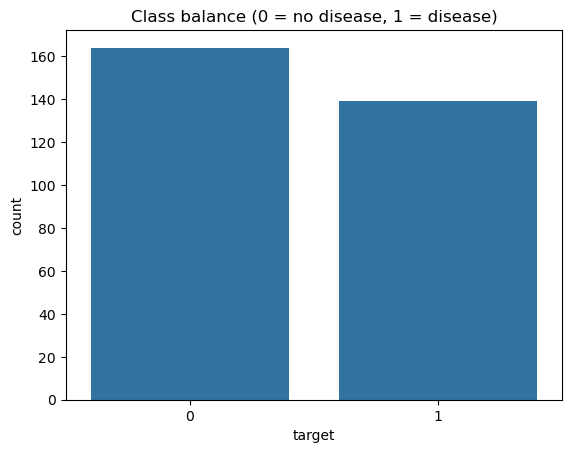

In [3]:
print(df['target'].value_counts())
sns.countplot(x='target', data=df)
plt.title('Class balance (0 = no disease, 1 = disease)')
plt.show()

In [4]:
df.corr(numeric_only=True)['target'].abs().sort_values(ascending=False)

target      1.000000
thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
thalach     0.417167
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
Name: target, dtype: float64

In [5]:
nominal_cols = ['cp', 'restecg', 'slope', 'thal']
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
binary_cols  = ['sex', 'fbs', 'exang']

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)

(242, 13) (61, 13)


In [6]:
preprocess = ColumnTransformer(transformers=[
    ('nom', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                       ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), nominal_cols),
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                       ('scale', StandardScaler())]), numeric_cols),
    ('bin', SimpleImputer(strategy='most_frequent'), binary_cols),
])

In [7]:
champion = Pipeline([
    ('preprocess', preprocess),
    (
        'm',
        SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    ),
])

# param_grid = {'m__C': [0.1, 0.5, 1, 2, 5, 10], 'm__gamma': ['scale', 'auto']}

# model_grids = {'SVC(rbf)': (champion, param_grid)}

champion.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('m', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nom', ...), ('num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


              precision    recall  f1-score   support

  No Disease       0.94      0.91      0.92        33
     Disease       0.90      0.93      0.91        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



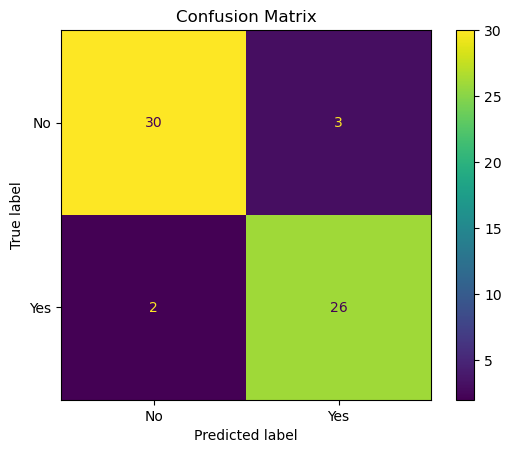

In [8]:
preds = champion.predict(X_test)
print(classification_report(y_test, preds, target_names=['No Disease', 'Disease']))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot()
plt.title(f'Confusion Matrix')
plt.show()

In [11]:
test_acc = round(accuracy_score(y_test, preds) * 100, 2)
print(f"Champion model:  'SVC(rbf)'")
print(f"Test accuracy: {test_acc}%")

Champion model:  'SVC(rbf)'
Test accuracy: 91.8%


In [12]:
import joblib
CHARGE_MODEL_FILE = "heart_model.pkl"

joblib.dump(champion, CHARGE_MODEL_FILE)

['heart_model.pkl']